In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks


General information on the hit rate of guides within our library
-
0) Here we leverage a feature that is typically ignored for CRISPR guide design, typically you want to ignore any off-target effects, but because we want to remove as much information as possible, we can leverage this to reduce the total number of guides necessary in our pool

1) We are targeting a massive genomic space, if we targeted a guide every 100bp that would lead to over 6 million guides which wouldn't be effective in an in vitro assay 

2) So in order to compress the space we leverage the fact that as long as non of the guides target the preserved contigs, we can select guides that hit the targeted contigs many times

3) this notebook adds further information about the number of guides in our library that hit many times and exactly how often

4) Biologically this can be attributed to repeat elements, kmers, transcription factor binding domains present in our targeted contigs 

In [2]:
guides = pd.read_csv('GREGOR_GUIDE/NEW_design_actual_samples/combined_supplemented_guides_ot_hit_rate.csv')
guides

,bin,contig,start,stop,target,score,otCount,window,contig_length
0,1,chr1:161540454-161552547,26,49,CTTCTGCCTTAGTGCTGTACGGG,0.292344,2,0-50,12093
1,1,chr1:161540454-161552547,72,95,GTTATCACTACAACCCTAGTCGG,0.485630,2,50-100,12093
2,1,chr1:161540454-161552547,109,132,TTTCCATAACGTAATTGCCGTGG,0.419782,2,100-150,12093
3,1,chr1:161540454-161552547,252,275,CGGGCACTATGTGTGGAACCTGG,0.379592,5,250-300,12093
4,1,chr1:161540454-161552547,278,301,TTAGTCACGCCGTGTACTGCTGG,0.387911,2,300-350,12093
...,...,...,...,...,...,...,...,...,...
500642,8,chr22:21853072-21853889,10,33,GCACTTTGGGAGGCCGAGGTGGG,0.396414,38042,repeat_guide,817
500643,8,chrX:1730805-1732723,272,295,GCACTTTGGGAGGCCGAGGTGGG,0.325238,38042,repeat_guide,1918
500644,8,chr22:41254151-41254992,572,595,GCACTTTGGGAGGCCGAGGTGGG,0.325238,38042,repeat_guide,841
500645,8,chrX:15837314-15838374,534,557,GCACTTTGGGAGGCCGAGGTGGG,0.325238,38042,repeat_guide,1060


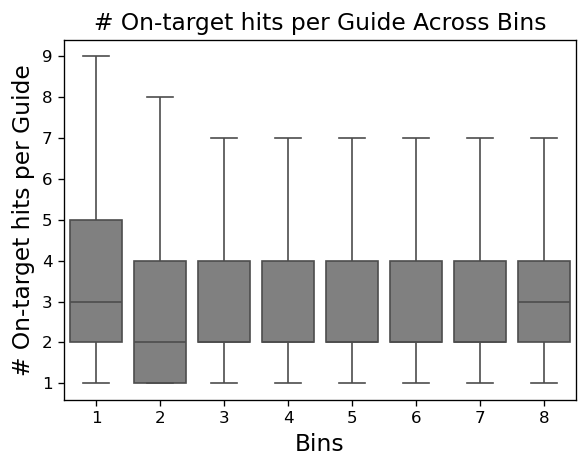

In [13]:
plt.figure(figsize=(5, 4), dpi=120)
sns.boxplot(data=guides, x='bin', y='otCount', color='gray', showfliers=False)
plt.title('# On-target hits per Guide Across Bins', fontsize=14)
plt.xlabel('Bins', fontsize=14)
plt.ylabel('# On-target hits per Guide', fontsize=14)
plt.tight_layout()
plt.savefig('GREGOR_GUIDE/figures/GREGOR_ontarget_hits_per_guide_distribution.png', dpi=300)
plt.show()

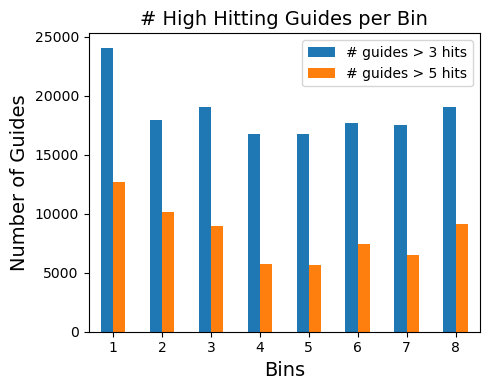

In [28]:
#total number of guides per bin with OT counts greater than 3
high_hits3 = guides[guides['otCount'] > 3].groupby('bin').size()
high_hits5 = guides[guides['otCount'] > 5].groupby('bin').size()

high_hits = pd.DataFrame({'# guides > 3 hits': high_hits3, '# guides > 5 hits': high_hits5})
high_hits.plot(kind='bar', figsize=(5, 4))
plt.title('# High Hitting Guides per Bin', fontsize=14)
plt.xticks(rotation=0)
plt.xlabel('Bins', fontsize=14)
plt.ylabel('Number of Guides', fontsize=14)
plt.tight_layout()
plt.savefig('GREGOR_GUIDE/figures/GREGOR_high_hitting_guides_per_bin.png', dpi=300)
plt.show()

<Figure size 600x500 with 0 Axes>

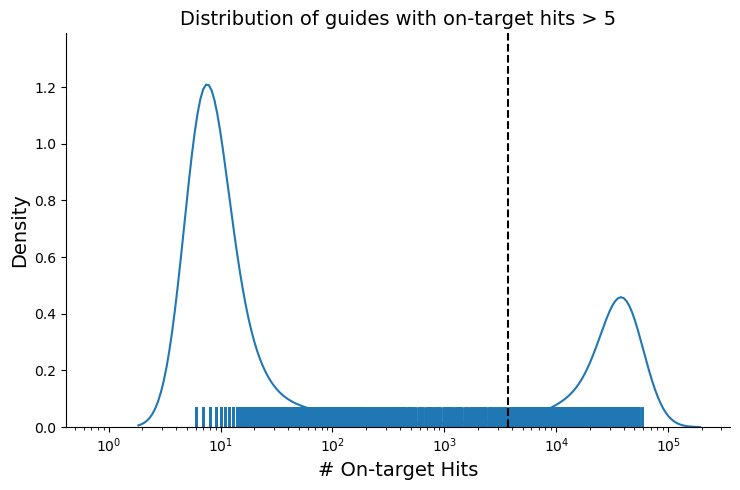

In [24]:
#now focus on the guides hitting more than 5 times to look at the distribution
repeat_hits = guides[guides['otCount']>5]
repeat_hits = repeat_hits.sort_values(by='otCount', ascending=False)

# Find local minimum between the peaks
hist, bin_edges = np.histogram(repeat_hits['otCount'], bins='auto', density=True)
log_bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Find peaks (which correspond to the modes)
peaks, _ = find_peaks(hist)

# Assuming the two most prominent peaks are the modes
if len(peaks) >= 2:
    # Find local minimum between the two primary peaks
    min_point = log_bin_centers[np.argmin(hist[min(peaks[0], peaks[1]):max(peaks[0], peaks[1])]) + min(peaks[0], peaks[1])]
else:
    min_point = None  

plt.figure(figsize=(6, 5))
sns.displot(x=list(repeat_hits.otCount), kind='kde', rug=True, aspect=1.5,
           rug_kws={"color": "r", "alpha": 0.3, "linewidth": 2, "height":0.05},
            log_scale=True)

plt.axvline(x=min_point, color='black', linestyle='--')
plt.title('Distribution of guides with on-target hits > 5', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.xlabel('# On-target Hits', fontsize=14)
plt.tight_layout()
plt.savefig('GREGOR_GUIDE/figures/GREGOR_high_hitting_guides_distribution.png', dpi=300)
plt.show()